# BR-DWGD em Curitiba

O BR-DWGD (Xavier et al., UFES/UTexas, v3.2.4) é precipitação de **pluviômetros interpolados** em grade de 0,1°, 1961-2025.
O ERA5-Land, alvo de todo o AT3, é reanálise. Este notebook olha as células do BR-DWGD em volta de Curitiba e compara com a
célula do ERA5-Land que o pipeline usa:

1. o que há nos arquivos e se está íntegro perto de Curitiba
2. quão parecidas são as células vizinhas entre si
3. qual dia do BR-DWGD corresponde ao dia UTC do ERA5-Land
4. quanto o ERA5-Land suaviza os dias fortes
5. se alguma das duas séries mostra mudança por década

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
pd.set_option("display.width", 140)

In [2]:
BRDWGD = Path("/media/mary-camila/Expansion/brdwgd/raw")
PASTA = Path("../../commons/data")
CACHE = PASTA / "curitiba_brdwgd_pr.parquet"     # a leitura lenta; apague para refazer

LAT, LON = -25.4284, -49.2733     # Praça Tiradentes, o mesmo ponto do pipeline
ERA5L_CELULA = (-25.4, -49.3)     # célula do ERA5-Land mais próxima (build_curitiba_daily.py)
RAIO = 0.25                       # caixa de ±0,25° em volta do ponto
LIMIAR = 10.0                     # R10mm

FIGDIR = Path("figuras_brdwgd")
FIGDIR.mkdir(exist_ok=True)

def salvar(nome, fig=None, dpi=200, fechar=False):
    """Salva a figura atual em PNG. Chame ANTES de plt.show()."""
    fig = fig or plt.gcf()
    fig.savefig(FIGDIR / f"{nome}.png", dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"salvo: {nome}.png")
    if fechar:
        plt.close(fig)

## Inventário

Duas pastas, cada variável em três arquivos por período. Os valores são `int16` com `scale_factor`, então a resolução da chuva é
fixa. O atributo `title` diz 1961-2020, mas o último arquivo vai até 2025.

In [3]:
linhas = []
for f in sorted(BRDWGD.glob("*/*.nc")):
    with xr.open_dataset(f) as ds:
        var = list(ds.data_vars)[0]
        enc = ds[var].encoding
        linhas.append({"pasta": f.parent.name[:12], "variável": var,
                       "início": pd.Timestamp(ds.time.values[0]).date(), "fim": pd.Timestamp(ds.time.values[-1]).date(),
                       "dias": ds.sizes["time"], "GB": round(f.stat().st_size / 1e9, 2),
                       "tipo": str(enc.get("dtype")), "resolução": enc.get("scale_factor")})
inventario = pd.DataFrame(linhas)
print(inventario.to_string(index=False))

       pasta variável     início        fim  dias   GB  tipo  resolução
ETo_u2_RH_Rs      ETo 1961-01-01 1980-12-31  7305 1.12 uint8   0.051181
ETo_u2_RH_Rs      ETo 1981-01-01 2000-12-31  7305 1.12 uint8   0.051181
ETo_u2_RH_Rs      ETo 2001-01-01 2025-12-31  9131 1.40 uint8   0.051181
ETo_u2_RH_Rs       RH 1961-01-01 1980-12-31  7305 1.12 uint8   0.393701
ETo_u2_RH_Rs       RH 1981-01-01 2000-12-31  7305 1.12 uint8   0.393701
ETo_u2_RH_Rs       RH 2001-01-01 2025-12-31  9131 1.40 uint8   0.393701
ETo_u2_RH_Rs       Rs 1961-01-01 1980-12-31  7305 1.12 uint8   0.157087
ETo_u2_RH_Rs       Rs 1981-01-01 2000-12-31  7305 1.12 uint8   0.157087
ETo_u2_RH_Rs       Rs 2001-01-01 2025-12-31  9131 1.40 uint8   0.157087
ETo_u2_RH_Rs       u2 1961-01-01 1980-12-31  7305 1.12 uint8   0.059055
ETo_u2_RH_Rs       u2 1981-01-01 2000-12-31  7305 1.12 uint8   0.059055
ETo_u2_RH_Rs       u2 2001-01-01 2025-12-31  9131 1.40 uint8   0.059055
pr_Tmax_Tmin     Tmax 1961-01-01 1980-12-31  7305 2.25 int16   0

## Extração em volta de Curitiba

Só a chuva, numa caixa de ±0,25° (5 × 5 células). Os três arquivos são concatenados e a continuidade é checada: um dia faltando
ou repetido entre arquivos desalinharia toda comparação com o ERA5-Land.

In [4]:
if CACHE.exists():
    pr = pd.read_parquet(CACHE)
    print(f"reusando {CACHE.name}")
else:
    partes = []
    for f in sorted((BRDWGD / "pr_Tmax_Tmin_NetCDF_Files").glob("pr_*.nc")):
        with xr.open_dataset(f) as ds:
            caixa = ds.pr.sel(latitude=slice(LAT - RAIO, LAT + RAIO), longitude=slice(LON - RAIO, LON + RAIO)).load()
        partes.append(caixa.to_dataframe().reset_index())
        print(f"  {f.name}: {caixa.sizes}")
    pr = pd.concat(partes, ignore_index=True)
    pr[["latitude", "longitude"]] = pr[["latitude", "longitude"]].round(2)
    pr = pr.rename(columns={"time": "date"})
    pr.to_parquet(CACHE)

# uma coluna por célula, nomeada "lat,lon"
grade = pr.pivot_table(index="date", columns=["latitude", "longitude"], values="pr")
print(f"{grade.shape[1]} células, {grade.index.min():%Y-%m-%d} a {grade.index.max():%Y-%m-%d}")

passos = grade.index.to_series().diff().dropna()
print("dias faltando ou repetidos:", int((passos != pd.Timedelta("1D")).sum()))
print("linhas duplicadas na extração:", int(pr.duplicated(["date", "latitude", "longitude"]).sum()))
print("NaN:", int(grade.isna().sum().sum()), "| negativos:", int((grade < 0).sum().sum()))
print(f"menor chuva positiva: {grade[grade > 0].min().min():.4f} mm (resolução do int16)")

  pr_19610101_19801231_BR-DWGD_UFES_UTEXAS_v_3.2.4.nc: Frozen({'time': 7305, 'latitude': 5, 'longitude': 5})


  pr_19810101_20001231_BR-DWGD_UFES_UTEXAS_v_3.2.4.nc: Frozen({'time': 7305, 'latitude': 5, 'longitude': 5})


  pr_20010101_20251231_BR-DWGD_UFES_UTEXAS_v_3.2.4.nc: Frozen({'time': 9131, 'latitude': 5, 'longitude': 5})
25 células, 1961-01-01 a 2025-12-31
dias faltando ou repetidos: 0
linhas duplicadas na extração: 0
NaN: 0 | negativos: 0
menor chuva positiva: 0.0206 mm (resolução do int16)


/tmp/ipykernel_13181/3670977446.py:21: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  print("dias faltando ou repetidos:", int((passos != pd.Timedelta("1D")).sum()))


In [5]:
# a célula do BR-DWGD que contém a Praça Tiradentes
lats = grade.columns.get_level_values(0).unique()
lons = grade.columns.get_level_values(1).unique()
CEL = (lats[np.abs(lats - LAT).argmin()], lons[np.abs(lons - LON).argmin()])
print("célula BR-DWGD da Praça Tiradentes:", CEL, "| célula ERA5-Land:", ERA5L_CELULA)
br = grade[CEL].rename("br_mm")

célula BR-DWGD da Praça Tiradentes: (np.float32(-25.45), np.float32(-49.25)) | célula ERA5-Land: (-25.4, -49.3)


## Mapa das células

Total anual médio por célula. O ponto é a Praça Tiradentes e o quadrado tracejado é a célula de 0,1° do ERA5-Land.

salvo: mapa_celulas.png


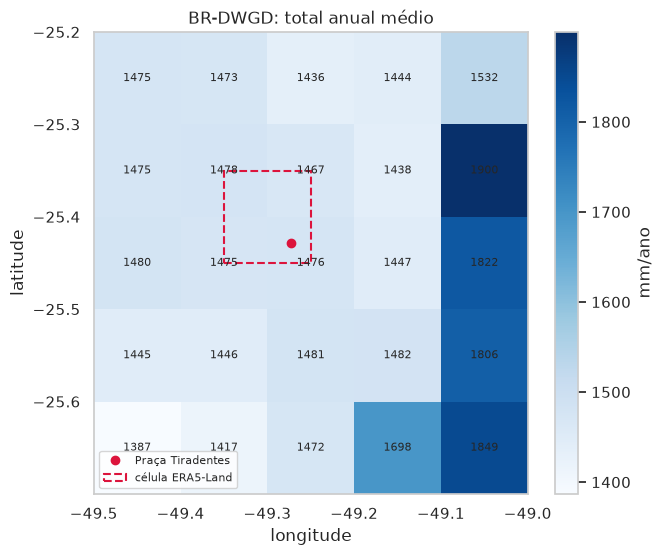

In [6]:
anos_br = grade.index.year
completos = pd.Series(anos_br).value_counts()
anos_ok = completos[completos >= 365].index
anual_cel = grade[anos_br.isin(anos_ok)].groupby(anos_br[anos_br.isin(anos_ok)]).sum().mean()
mapa = anual_cel.unstack().sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(mapa.columns, mapa.index, mapa.values, cmap="Blues", shading="nearest")
fig.colorbar(im, ax=ax, label="mm/ano")
for (la, lo), v in anual_cel.items():
    ax.text(lo, la, f"{v:.0f}", ha="center", va="center", fontsize=8)
ax.plot(LON, LAT, "o", color="crimson", label="Praça Tiradentes")
la0, lo0 = ERA5L_CELULA
ax.add_patch(plt.Rectangle((lo0 - .05, la0 - .05), .1, .1, fill=False, ls="--", color="crimson", lw=1.5,
                           label="célula ERA5-Land"))
ax.set(title="BR-DWGD: total anual médio", xlabel="longitude", ylabel="latitude")
ax.legend(loc="lower left", fontsize=8)
salvar("mapa_celulas")
plt.show()

## Homogeneidade entre células

Se as células vizinhas forem quase iguais, a escolha da célula não importa. Se não forem, a interpolação está mudando de estação
de referência dentro da cidade, e isso precisa entrar na comparação.

In [7]:
dist = {c: np.hypot(c[0] - CEL[0], c[1] - CEL[1]) for c in grade.columns}
viz = pd.DataFrame({
    "dist_graus": dist,
    "corr_diaria": {c: grade[c].corr(br) for c in grade.columns},
    "concorda_R10": {c: ((grade[c] >= LIMIAR) == (br >= LIMIAR))[(grade[c] >= LIMIAR) | (br >= LIMIAR)].mean()
                     for c in grade.columns},
    "total_anual": anual_cel,
}).sort_values("dist_graus")
print(viz.round(3).to_string())

                       dist_graus  corr_diaria  concorda_R10  total_anual
-25.450001 -49.250000       0.000        1.000         1.000     1476.046
-25.549999 -49.250000       0.100        0.968         0.803     1480.625
-25.450001 -49.349998       0.100        0.953         0.767     1474.779
           -49.150002       0.100        0.947         0.748     1446.572
-25.350000 -49.250000       0.100        0.934         0.734     1467.181
-25.549999 -49.150002       0.141        0.936         0.718     1481.882
           -49.349998       0.141        0.927         0.719     1445.867
-25.350000 -49.349998       0.141        0.907         0.680     1477.764
           -49.150002       0.141        0.896         0.668     1438.329
-25.650000 -49.250000       0.200        0.881         0.629     1472.498
-25.450001 -49.450001       0.200        0.883         0.630     1479.860
           -49.049999       0.200        0.824         0.545     1821.527
-25.250000 -49.250000       0.200     

## Alinhamento com o ERA5-Land

O ERA5-Land do pipeline soma o dia UTC, de 00h a 24h. Pluviômetro costuma ser lido de manhã e a leitura vai para um dos dois dias
que ela cobre. Em vez de supor, a correlação para deslocamentos de -2 a +2 dias mostra qual dia do BR-DWGD corresponde ao dia do ERA5-Land.

In [8]:
era = pd.read_parquet(PASTA / "curitiba_daily.parquet").set_index("date").tp_mm.rename("era_mm")
era.index = pd.to_datetime(era.index)

alin = pd.DataFrame([{"desloc_dias": k,
                      "pearson": era.corr(br.shift(-k)),
                      "spearman": era.corr(br.shift(-k), method="spearman")}
                     for k in range(-2, 3)]).set_index("desloc_dias")
print("br.shift(-k): k > 0 compara o ERA5-Land do dia t com o BR-DWGD do dia t+k")
print(alin.round(3).to_string())
K = int(alin.pearson.idxmax())
print(f"\nmelhor deslocamento: {K:+d} dia(s)")

br.shift(-k): k > 0 compara o ERA5-Land do dia t com o BR-DWGD do dia t+k
             pearson  spearman
desloc_dias                   
-2             0.054     0.154
-1             0.120     0.283
 0             0.462     0.592
 1             0.439     0.610
 2             0.109     0.290

melhor deslocamento: +0 dia(s)


In [9]:
par = pd.concat([era, br.shift(-K)], axis=1, join="inner").dropna()
par["ano"] = par.index.year
print(f"{len(par)} dias em comum, {par.index.min():%Y-%m-%d} a {par.index.max():%Y-%m-%d}, BR-DWGD deslocado {K:+d}")

16710 dias em comum, 1980-04-01 a 2025-12-30, BR-DWGD deslocado +0


## Quanto o ERA5-Land suaviza

Dias com 10 mm ou mais por ano, quantis dos dias chuvosos e a tabela de contingência do R10mm. O que importa para o AT3 é se os dias
fortes do ERA5-Land são os mesmos dias fortes dos pluviômetros.

In [10]:
anos_par = par.groupby("ano").size()
p_ok = par[par.ano.isin(anos_par[anos_par >= 360].index)]
resumo = pd.DataFrame({
    fonte: {"total_anual_mm": p_ok.groupby("ano")[c].sum().mean(),
            "dias_R10_por_ano": (p_ok[c] >= LIMIAR).groupby(p_ok.ano).sum().mean(),
            "dias_R50_por_ano": (p_ok[c] >= 50).groupby(p_ok.ano).sum().mean(),
            "maior_dia_mm": p_ok[c].max()}
    for fonte, c in [("ERA5-Land", "era_mm"), ("BR-DWGD", "br_mm")]})
print(resumo.round(1).to_string())

chuv = {fonte: par[c][par[c] >= 1] for fonte, c in [("ERA5-Land", "era_mm"), ("BR-DWGD", "br_mm")]}
print("\nquantis dos dias chuvosos (>= 1 mm):")
print(pd.DataFrame({k: v.quantile([.5, .9, .95, .99, .999]) for k, v in chuv.items()}).round(1).to_string())

e, b = par.era_mm >= LIMIAR, par.br_mm >= LIMIAR
cont = pd.crosstab(e.rename("ERA5-Land >= 10"), b.rename("BR-DWGD >= 10"))
print("\n", cont.to_string())
print(f"\ndos dias fortes do BR-DWGD, o ERA5-Land também marca: {(e & b).sum() / b.sum():.2f}")
print(f"dos dias fortes do ERA5-Land, o BR-DWGD também marca: {(e & b).sum() / e.sum():.2f}")

                  ERA5-Land  BR-DWGD
total_anual_mm       1554.8   1504.6
dias_R10_por_ano       52.2     49.6
dias_R50_por_ano        1.4      2.3
maior_dia_mm          192.7    116.6

quantis dos dias chuvosos (>= 1 mm):
       ERA5-Land  BR-DWGD
0.500        5.3      6.7
0.900       18.9     27.1
0.950       25.7     35.9
0.990       46.6     57.4
0.999       79.8     96.1

 BR-DWGD >= 10    False  True 
ERA5-Land >= 10              
False            13041   1274
True              1395   1000

dos dias fortes do BR-DWGD, o ERA5-Land também marca: 0.44
dos dias fortes do ERA5-Land, o BR-DWGD também marca: 0.42


salvo: era5land_vs_brdwgd.png


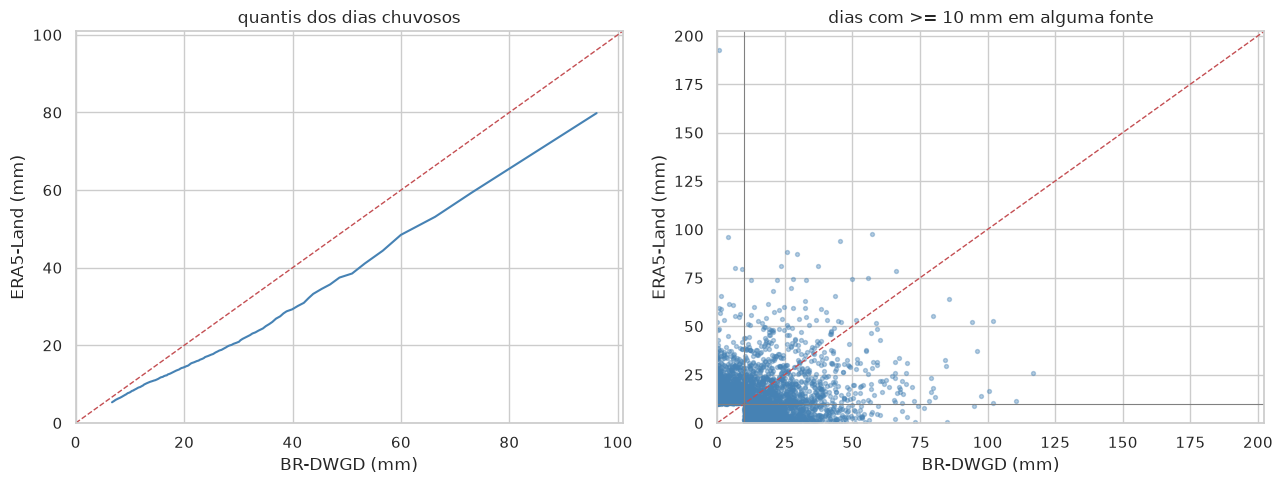

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

q = np.linspace(.5, .999, 200)
axes[0].plot(chuv["BR-DWGD"].quantile(q), chuv["ERA5-Land"].quantile(q), color="steelblue")
lim = [0, max(chuv["BR-DWGD"].quantile(.999), chuv["ERA5-Land"].quantile(.999)) * 1.05]
axes[0].plot(lim, lim, "r--", lw=1)
axes[0].set(title="quantis dos dias chuvosos", xlabel="BR-DWGD (mm)", ylabel="ERA5-Land (mm)", xlim=lim, ylim=lim)

f = par[(par.era_mm >= LIMIAR) | (par.br_mm >= LIMIAR)]
axes[1].scatter(f.br_mm, f.era_mm, s=8, alpha=.4, color="steelblue")
lim = [0, f[["br_mm", "era_mm"]].max().max() * 1.05]
axes[1].plot(lim, lim, "r--", lw=1)
axes[1].axhline(LIMIAR, color="gray", lw=.8); axes[1].axvline(LIMIAR, color="gray", lw=.8)
axes[1].set(title=f"dias com >= {LIMIAR:g} mm em alguma fonte", xlabel="BR-DWGD (mm)", ylabel="ERA5-Land (mm)",
            xlim=lim, ylim=lim)
plt.tight_layout()
salvar("era5land_vs_brdwgd")
plt.show()

## Décadas

O BR-DWGD começa em 1961, vinte anos antes do ERA5-Land do disco. Mann-Kendall (tendência, com inclinação de Sen por década) e
Pettitt (ponto de mudança) na série anual. Se as duas fontes discordarem sobre uma mudança, ela pode ser do produto e não do clima.

In [12]:
def mann_kendall(x):
    t = np.arange(len(x))
    tau, p = stats.kendalltau(t, x)
    return tau, p, stats.theilslopes(x, t).slope * 10

def pettitt(x):
    x = np.asarray(x); n = len(x)
    U = np.array([np.sign(x[:k + 1, None] - x[None, k + 1:]).sum() for k in range(n - 1)])
    k = np.abs(U).argmax()
    return k, min(1.0, 2 * np.exp(-6 * U[k] ** 2 / (n ** 3 + n ** 2)))

def anual(s):
    s = s[s.index.year.isin(pd.Series(s.index.year).value_counts().loc[lambda v: v >= 360].index)]
    forte = s[s >= LIMIAR]
    a = pd.DataFrame({"total_mm": s.groupby(s.index.year).sum(),
                      "dias_R10": forte.groupby(forte.index.year).size(),
                      "intens_media": forte.groupby(forte.index.year).mean(),
                      "p90_fortes": forte.groupby(forte.index.year).quantile(.9),
                      "max_dia": s.groupby(s.index.year).max()})
    return a

series = {"BR-DWGD": anual(br), "ERA5-Land": anual(era)}
for fonte, a in series.items():
    print(f"\n{fonte}: {a.index.min()}-{a.index.max()}, médias por década")
    print(a.groupby(a.index // 10 * 10).mean().assign(n_anos=a.groupby(a.index // 10 * 10).size()).round(1).to_string())


BR-DWGD: 1961-2025, médias por década
      total_mm  dias_R10  intens_media  p90_fortes  max_dia  n_anos
date                                                               
1960    1409.8      45.2          22.0        38.8     63.7       9
1970    1405.0      45.2          21.1        34.9     60.1      10
1980    1380.7      43.7          21.9        36.2     58.9      10
1990    1661.5      55.2          23.6        38.7     76.1      10
2000    1481.6      49.6          23.1        39.1     68.9      10
2010    1579.3      52.9          23.3        40.5     78.1      10
2020    1362.2      45.3          20.8        37.7     67.1       6

ERA5-Land: 1981-2025, médias por década
         total_mm  dias_R10  intens_media  p90_fortes    max_dia  n_anos
date                                                                    
1980  1487.400024      50.4     18.600000        30.1  55.400002       9
1990  1732.800049      56.3     20.299999        34.4  79.500000      10
2000  1503.90002

In [13]:
linhas = []
for fonte, a in series.items():
    for c in a.columns:
        x = a[c].to_numpy()
        tau, p_mk, sen = mann_kendall(x)
        k, p_pt = pettitt(x)
        linhas.append({"fonte": fonte, "série": c, "MK_tau": tau, "MK_p": p_mk, "Sen_por_decada": sen,
                       "Pettitt_após": a.index[k], "Pettitt_p": p_pt,
                       "antes": x[:k + 1].mean(), "depois": x[k + 1:].mean()})
print(pd.DataFrame(linhas).set_index(["série", "fonte"]).sort_index().round(2).to_string())

                        MK_tau  MK_p  Sen_por_decada  Pettitt_após  Pettitt_p    antes   depois
série        fonte                                                                             
dias_R10     BR-DWGD      0.09  0.27            0.71          1989       0.09    44.69    51.36
             ERA5-Land   -0.03  0.79           -0.00          2015       0.59    53.63    47.30
intens_media BR-DWGD      0.08  0.34            0.14          1985       0.08    21.43    22.94
             ERA5-Land   -0.03  0.74           -0.08          1998       0.49    19.58    18.85
max_dia      BR-DWGD      0.15  0.08            1.87          1992       0.04    60.43    74.63
             ERA5-Land    0.09  0.37            2.12          1993       0.34    55.41    67.85
p90_fortes   BR-DWGD      0.15  0.09            0.77          1994       0.13    36.45    39.66
             ERA5-Land   -0.03  0.78           -0.20          1999       0.49    32.40    29.94
total_mm     BR-DWGD      0.06  0.48    

salvo: series_anuais.png


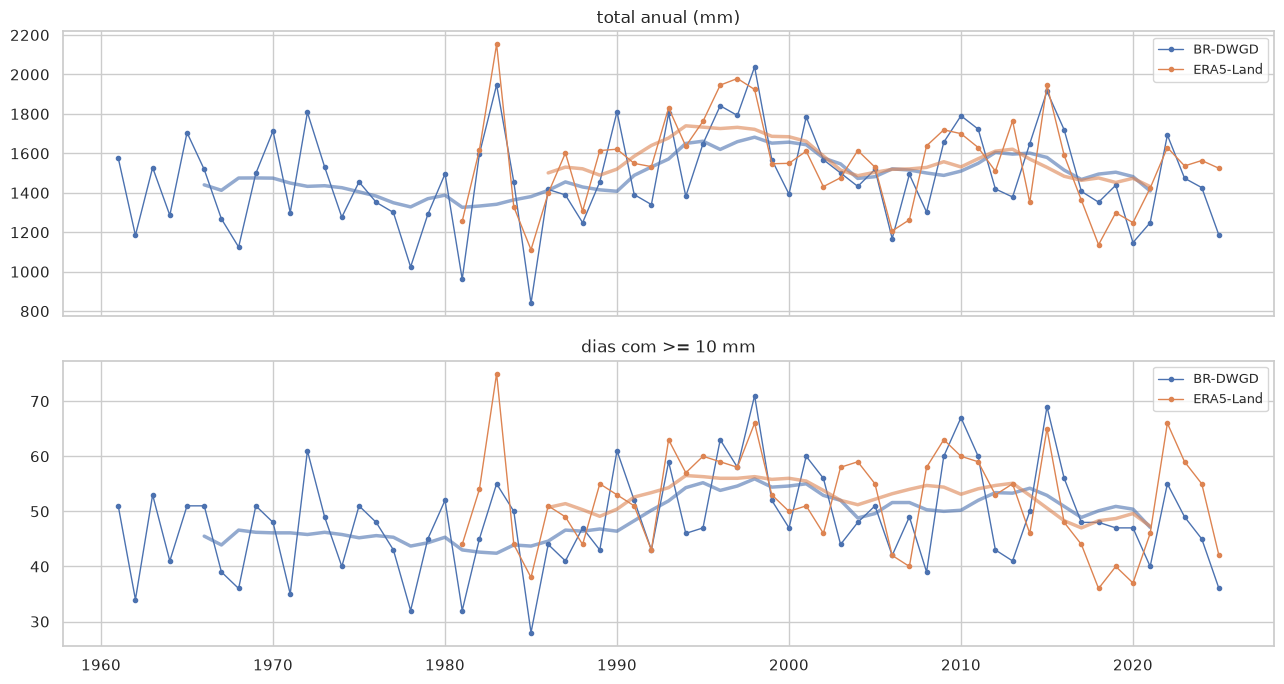

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, c, titulo in zip(axes, ["total_mm", "dias_R10"], ["total anual (mm)", "dias com >= 10 mm"]):
    for fonte, a in series.items():
        ax.plot(a.index, a[c], "-o", ms=3, lw=1, label=fonte)
        ax.plot(a.index, a[c].rolling(10, center=True).mean(), lw=2.5, alpha=.6,
                color=ax.lines[-1].get_color())
    ax.set(title=titulo, ylabel="")
    ax.legend(fontsize=9)
plt.tight_layout()
salvar("series_anuais")
plt.show()